(Subdomain-ADR)=
# Subdomains ADR

We demonstrate here how to solve general bulk or surface ADR equations on different domain parts.

Let's start by creating a geometry with two subdomains

In [1]:
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *   # Opencascade for geometry modeling
import pandas as pd
import matplotlib.pyplot as plt

outer = Rectangle(2, 2).Face()
outer.edges.name="outer"
outer.edges.Max(X).name = "r"
outer.edges.Min(X).name = "l"
outer.edges.Min(Y).name = "b"
outer.edges.Max(Y).name = "t"

inner = MoveTo(0.5, 0.5).Rectangle(1, 1).Face()
inner.edges.name="interface"
outer = outer - inner

inner.faces.name="inner"
inner.faces.col = (1, 0, 0)
outer.faces.name="outer"

geo = Glue([inner, outer])

mesh = Mesh(OCCGeometry(geo, dim=2).GenerateMesh(maxh=0.1))
Draw(mesh);

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Let's initialize the simulation with the respective time parameters

In [2]:
from cosmos.solvers.simulation import Simulation

dt = Parameter(0.05)
T = 1.0
t = Parameter(0)
simulation = Simulation(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  510
     edges is:  1447
     faces is:  938
     facets is:  1447
     elements is:  938 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  inner
 N.  1 region(s) called  outer
Regions of co-dimension  1 :
 N.  4 region(s) called  interface
 N.  1 region(s) called  b
 N.  1 region(s) called  l
 N.  1 region(s) called  r
 N.  1 region(s) called  t
Regions of co-dimension  2 :
 N.  8 region(s) called  default
------------------------------------------------------------ 



Let's create the solver and add it to the simulation

In [3]:
from cosmos.solvers.adr import ADRSolver
solver = ADRSolver()
simulation.AddSolver(solver)

------------------------------------------------------------
This is a general solver for a Advection-Diffusion-Reaction problem.
               It allows to solve surface, bulk and coupled surface-bulk equations.
               It uses conforming H-1 elements of order 1.
Its parameters are
  - linear - with value  False
------------------------------------------------------------ 



At this point we need to prescribe the coefficients of our ADR equations. Note that 
- one has to be aware where the normal of the various subdomains is pointing. For example in this case the normal of the inner square is pointing outward, thus we need to adjust the boundary conditions of the two species in accordance to that.

We create manufactured solutions for both so that later we can use it to see the error.

In [4]:
from cosmos.solvers.tools import gradient

# Solver 1
u_ex1 = cos(pi*x)*sin(pi*y)*cos(t)
d1 = 1 + x**2
c1 = 1 + x**2
b1 = CF((sin(x), 1))
flux1 = b1*u_ex1 - d1*gradient(u_ex1, Id(2))
rhs1 = (u_ex1.Diff(t) + Trace(gradient(flux1, Id(2))) + c1*u_ex1).Compile()
dir_d1 = {'interface': u_ex1}
dir_b1 = {'interface': u_ex1}
neu_b1 = {'interface|r|l|b|t': b1*u_ex1}
neu_d1 = {'interface|r|l|b|t': - d1*gradient(u_ex1, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs1,
                advection = b1,
                diffusion = d1,
                reaction = c1,
                u0 = u_ex1,
                neu_d = neu_d1,
                neu_b = neu_b1,
                domain = 'inner')

# Solver 1
u_ex2 = cos(pi*x)*cos(t)
d2 = 1 + x**2
c2 = 1 + t**2
b2 = CF((0, 0))
flux2 = b2*u_ex2 - d2*gradient(u_ex2, Id(2))
rhs2 = (u_ex2.Diff(t) + Trace(gradient(flux2, Id(2))) + c2*u_ex2).Compile()
neu_b2 = {'r|l|b|t': b2*u_ex2,
              'interface': -b2*u_ex2}
neu_d2 = {'r|l|b|t': - d2*gradient(u_ex2, Id(2)),
              'interface': d2*gradient(u_ex2, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs2,
                advection = b2,
                diffusion = d2,
                reaction = c2,
                u0 = u_ex2,
                neu_b = neu_b2,
                neu_d = neu_d2,
                domain = 'outer')

solver.ComputeError(ex_sol = [u_ex1, u_ex2], norm = 'L2', folderpath = './adr_results/', filename = 'subdomains_adr_errors')

We can finally run the simulation and plot the final result, comparing it with the exact solution.

In [5]:
simulation.run()

print('\nComputed solutions')

solver.draw_solution()

print('\nExact solutions - defined everywhere')

Draw(u_ex1, mesh)
Draw(u_ex2, mesh)


Initializing...
Initialization successful 
                    N. 1  solvers have been initialized correctly
---------- 
Starting the simulation...


	 Running Simulation...: 100%|█████████████| 20/20 [00:00<00:00, 29.34it/s]

Simulation concluded successfully
----------

Computed solutions


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…


Exact solutions - defined everywhere


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

Loading the errors file, we can see how it behaves at every timestep

    Time   specie0   specie1
0   0.00  0.004536  0.005319
1   0.05  0.006366  0.006729
2   0.10  0.006965  0.007981
3   0.15  0.007108  0.008741
4   0.20  0.007112  0.009192
5   0.25  0.007059  0.009457
6   0.30  0.006974  0.009605
7   0.35  0.006866  0.009673
8   0.40  0.006738  0.009681
9   0.45  0.006592  0.009641
10  0.50  0.006430  0.009559
11  0.55  0.006251  0.009438
12  0.60  0.006056  0.009279
13  0.65  0.005847  0.009085
14  0.70  0.005622  0.008857
15  0.75  0.005384  0.008594
16  0.80  0.005132  0.008300
17  0.85  0.004868  0.007974
18  0.90  0.004591  0.007620
19  0.95  0.004303  0.007237
20  1.00  0.004004  0.006830


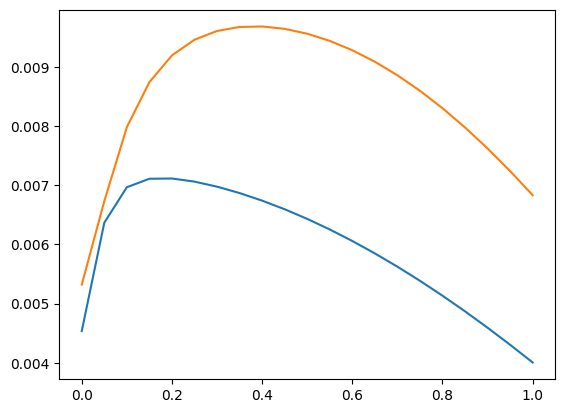

In [6]:
file_path = "./adr_results/subdomains_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['specie0'])
plt.plot(df['Time'], df['specie1'])
plt.show()

We can repeat the same procedure for a moving domain as follows

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'ngsolve_version': 'Netgen x.x', 'mesh_dim': …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

------------------------------------------------------------
The mesh is a  2D mesh
The number of:
     vertices is:  338
     edges is:  948
     faces is:  611
     facets is:  948
     elements is:  611 ( = 0 if hypersurface)
Regions of co-dimension  0 :
 N.  1 region(s) called  inner
 N.  1 region(s) called  outer
Regions of co-dimension  1 :
 N.  1 region(s) called  interface
 N.  1 region(s) called  outer
Regions of co-dimension  2 :
 N.  2 region(s) called  default
------------------------------------------------------------ 

------------------------------------------------------------
This is a general solver for a Advection-Diffusion-Reaction problem.
               It allows to solve surface, bulk and coupled surface-bulk equations.
               It uses conforming H-1 elements of order 1.
Its parameters are
  - linear - with value  True
------------------------------------------------------------ 

Initializing...
Initialization successful 
                    N. 1  solver

Running Simulation...: 100%|███████████████| 10/10 [00:00<00:00, 76.72it/s]

Simulation concluded successfully
----------
Computed solutions


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time   specie0   specie1
0    0.0  0.004940  0.005591
1    0.1  0.008317  0.019887
2    0.2  0.009878  0.022866
3    0.3  0.010408  0.023475
4    0.4  0.010551  0.023196
5    0.5  0.010441  0.022376
6    0.6  0.010075  0.021105
7    0.7  0.009491  0.019481
8    0.8  0.008743  0.017704
9    0.9  0.007914  0.015971
10   1.0  0.007023  0.014499


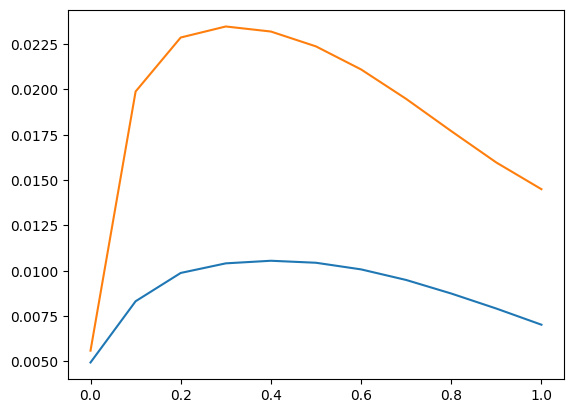

In [7]:
outer = Circle((0,0), 1).Face()
outer.edges.name="outer"

inner = Circle((0,0), 0.5).Face()
inner.edges.name="interface"
outer = outer - inner

inner.faces.name="inner"
inner.faces.col = (1, 0, 0)
outer.faces.name="outer"

geo = Glue([inner, outer])
Draw(geo);

mesh = Mesh(OCCGeometry(geo, dim=2).GenerateMesh(maxh=0.1))
Draw(mesh);

from cosmos.solvers.simulation import MovingSimulation

dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = MovingSimulation(mesh=mesh, t=t, dt = dt, T = T, verbose = 2)

A = CF(((1+0.25*sin(t))*cos(t), -sin(t),\
                sin(t), (1-0.25*sin(t))*cos(t)), dims = (2,2))
B = CF((0.2*t, 0.1*t))
phi = A*CF((x,y)) + B # Deformation map
detJ = Det(A)
invA = Cof(A).trans/detJ
inv_phi = invA*(CF((x,y)) - B) # Inverse of deformation map
w_phi = A.Diff(t)*inv_phi + B.Diff(t) # velocity of the moving domain
displ_ex = phi - CF((x,y))

simulation.AddMotion(function = displ_ex, domain = '.*', prescribed_everywhere = True)

solver = ADRSolver(linear = True)
simulation.AddSolver(solver)


# Solver 1
u_ex1 = cos(pi*x)*sin(pi*y)*cos(t)
d1 = 1 + x**2
c1 = 1 + x**2
b1 = CF((sin(x), 1))
flux1 = b1*u_ex1 - d1*gradient(u_ex1, Id(2)) + w_phi*u_ex1
rhs1 = (u_ex1.Diff(t) + Trace(gradient(flux1, Id(2))) + c1*u_ex1).Compile()
dir_b1 = {'interface': u_ex1}
dir_d1 = {'interface': u_ex1}
neu_b1 = {'interface': b1*u_ex1}
neu_d1 = {'interface': - d1*gradient(u_ex1, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs1,
                advection = b1,
                diffusion = d1,
                reaction = c1,
                u0 = u_ex1,
                neu_d = neu_d1,
                neu_b = neu_b1,
                domain = 'inner')

# Solver 1
u_ex2 = cos(pi*x)*cos(t)
d2 = 1 + x**2
c2 = 1 + t**2
b2 = CF((sin(x), 2))
flux2 = b2*u_ex2 - d2*gradient(u_ex2, Id(2)) + w_phi*u_ex2
rhs2 = (u_ex2.Diff(t) + Trace(gradient(flux2, Id(2))) + c2*u_ex2).Compile()
dir_b2 = {'interface': u_ex2}
dir_d2 = {'interface': u_ex2}
neu_b2 = {'outer': b2*u_ex2}
neu_d2 = {'outer': - d2*gradient(u_ex2, Id(2))}
solver.AddSpecie(VorB = VOL,
                rhs = rhs2,
                advection = b2,
                diffusion = d2,
                reaction = c2,
                u0 = u_ex2,
                neu_d = neu_d2,
                neu_b = neu_b2,
                dir_d = dir_d2,
                dir_b = dir_b2,
                domain = 'outer')

solver.ComputeError(ex_sol = [u_ex1, u_ex2], norm = 'L2', folderpath = './adr_results/', filename = 'subdomains1_adr_errors')

simulation.run()

print('Computed solutions')

solver.draw_solution()

file_path = "./adr_results/subdomains1_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['specie0'])
plt.plot(df['Time'], df['specie1'])
plt.show()
# %%

And for a surface

Running Simulation...: 100%|███████████████| 10/10 [00:02<00:00,  3.99it/s]

Computed solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Exact solution


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

    Time   specie0   specie1
0    0.0  0.008131  0.006035
1    0.1  0.022075  0.036533
2    0.2  0.026809  0.051904
3    0.3  0.027029  0.057367
4    0.4  0.025531  0.057699
5    0.5  0.023428  0.055484
6    0.6  0.021641  0.051936
7    0.7  0.021141  0.047612
8    0.8  0.022011  0.042390
9    0.9  0.022890  0.036596
10   1.0  0.022035  0.032610


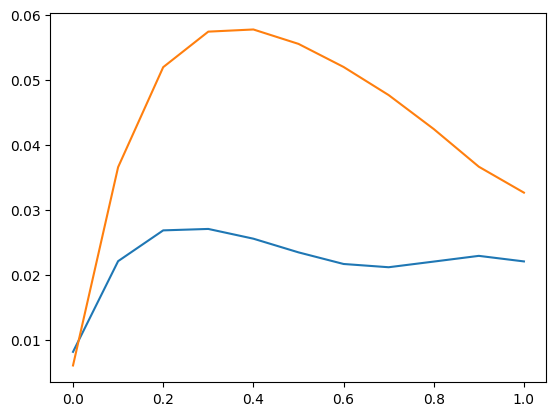

In [11]:
from netgen.csg import *
from netgen.meshing import MeshingStep

geo          = CSGeometry()
sphere       = Sphere(Pnt(0,0,0), 1)
sphere1      = Sphere(Pnt(0,0,0), 1)
bot          = Plane(Pnt(0,0,0), Vec(0,-1,0))
bot1          = Plane(Pnt(0,0,0), Vec(0,1,0))
finitesphere1 = sphere * bot
finitesphere2 = sphere1 * bot1
finitesphere1.bc('surface1')
finitesphere2.bc('surface2')

geo.AddSurface(sphere, finitesphere1)
geo.AddSurface(sphere1, finitesphere2)
geo.NameEdge(sphere,bot, "boundary")


mesh = Mesh(geo.GenerateMesh(maxh=0.1, perfstepsend=MeshingStep.MESHSURFACE))


dt = Parameter(0.1)
T = 1
t = Parameter(0)
simulation = MovingSimulation(mesh=mesh, t=t, dt = dt, T = T)

from cosmos.solvers.tools import sphere_transformation

A = CF(((1+0.25*sin(t))*cos(t), -sin(t), 0,\
                sin(t), (1-0.25*sin(t))*cos(t), 0,\
                    0, 0, 1), dims = (3,3))
B = CF((0.2*t, 0.1*t, 0))
phi, inv_phi, w_phi, detJ, n_ex = sphere_transformation(A, B, t)
# phi, inv_phi, w_phi, detJ, n_ex = get_lin_trans_params(A, B, t)
# phi is the deformation map
# inv_phi is its inverse
# w_phi is the velocity of the domain
# n_ex is the normal to the surface
P_ex = Id(3) - OuterProduct(n_ex, n_ex)
displ_ex = phi - CF((x,y,z))

simulation.AddMotion(function = displ_ex, domain = '.*', prescribed_everywhere = True)

solver = ADRSolver(linear = True)
simulation.AddSolver(solver)

u_ex1 = cos(pi*x)*sin(pi*y)*cos(t)
d1 = 1 + x**2
c1 = 1 + t**2
b1 = P_ex*CF((0,0,0))
flux_c1 = (b1*u_ex1).Compile()
flux_d1 = (- d1*gradient(u_ex1, P_ex)).Compile()
flux1 = flux_c1 + flux_d1
rel_flux1 = u_ex1*Trace(gradient(w_phi, P_ex)) + w_phi*gradient(u_ex1, Id(3))
rhs1 = (u_ex1.Diff(t) + rel_flux1 + Trace(gradient(flux1, P_ex)) + c1*u_ex1).Compile()
neu_b1 = {'boundary': flux_c1}
neu_d1 = {'boundary': flux_d1}
dir_d1 = {'boundary': u_ex1}
dir_b1 = {'boundary': u_ex1}

solver.AddSpecie(VorB = BND,
            rhs = rhs1,
            advection = b1,
            diffusion = d1,
            reaction = c1,
            u0 = u_ex1,
            dir_b = dir_b1,
            dir_d = dir_d1,
            domain = 'surface1')

u_ex2 = sin(pi*x)*cos(t)
d2 = 1 + x**2
c2 = 1 + t**2
b2 = P_ex*CF((2,1,0))
flux_c2 = (b2*u_ex2).Compile()
flux_d2 = (- d2*gradient(u_ex2, P_ex)).Compile()
flux2 = flux_c2 + flux_d2
rel_flux2 = u_ex2*Trace(gradient(w_phi, P_ex)) + w_phi*gradient(u_ex2, Id(3))
rhs2 = (u_ex2.Diff(t) + rel_flux2 + Trace(gradient(flux2, P_ex)) + c2*u_ex2).Compile()
neu_b2 = {'boundary': flux_c2}
neu_d2 = {'boundary': flux_d2}
dir_d2 = {'boundary': u_ex2}
dir_b2 = {'boundary': u_ex2}

solver.AddSpecie(VorB = BND,
            rhs = rhs2,
            advection = b2,
            diffusion = d2,
            reaction = c2,
            u0 = u_ex2,
            neu_d = neu_d2,
            neu_b = neu_b2,
            domain = 'surface2')

solver.ComputeError(ex_sol = [u_ex1, u_ex2], norm = 'L2', folderpath = './adr_results/', filename = 'subdomains2_adr_errors')
solver.SaveSolution(folderpath = './adr_results/', filename = 'subdomain2_adr_errors', n_steps = 100)

    
simulation.run()

print('Computed solution')
solver.draw_solution()
print('Exact solution')
mesh.SetDeformation(simulation.data['dX'])
Draw(u_ex1, mesh)
Draw(u_ex2, mesh)
mesh.UnsetDeformation()

file_path = "./adr_results/subdomains2_adr_errors"

# Read the CSV into a DataFrame
df = pd.read_csv(file_path)

print(df)

plt.plot(df['Time'], df['specie0'])
plt.plot(df['Time'], df['specie1'])
plt.show()